## 1. Imports

# Fine-tuning with LoRA

In [25]:
import json
import logging
import os
from pathlib import Path
from typing import Any, cast

import matplotlib.pyplot as plt
import mlx.nn as nn
import mlx.optimizers as optim
import pandas as pd
import torch
from mlx.utils import tree_flatten
from mlx_lm.generate import generate
from mlx_lm.tuner import datasets
from mlx_lm.tuner.callbacks import TrainingCallback
from mlx_lm.tuner.trainer import TrainingArgs, train
from mlx_lm.tuner.utils import linear_to_lora_layers
from mlx_lm.utils import load
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from transformers import PreTrainedTokenizer

## 2. Metrics Callback

In [26]:
class Metrics(TrainingCallback):
    """A simple class to collect training and validation metrics."""
    
    def __init__(self) -> None:
        self.train_losses: list[tuple[int, float]] = []
        self.val_losses: list[tuple[int, float]] = []

    def on_train_loss_report(self, info: dict[str, Any]) -> None:
        self.train_losses.append((info["iteration"], info["train_loss"]))

    def on_val_loss_report(self, info: dict[str, Any]) -> None:
        self.val_losses.append((info["iteration"], info["val_loss"]))

## 3. Utility Functions

In [27]:
def find_project_root(marker=".git"):
    """Find the root directory of the project based on a marker file or directory."""
    path = Path(os.getcwd()).resolve()
    for parent in [path] + list(path.parents):
        if (parent / marker).exists():
            return parent
    return path


def df_to_str_dicts(df: pd.DataFrame) -> list[dict[str, str]]:
    """Convert DataFrame to list of string dictionaries.

    Args:
        df: DataFrame to convert

    Returns:
        List of dictionaries with string keys and values
    """
    records = df.to_dict(orient="records")
    result: list[dict[str, str]] = []

    for record in records:
        str_record = {
            str(k): str(v) if not pd.isna(v) else "" for k, v in record.items()
        }
        result.append(str_record)

    return result


def load_essay(
    file_path: Path | str,
    encoding: str = "utf-8",
) -> pd.DataFrame:
    """Load dataset from a single JSONL file.

    Args:
        file_path: Path to the JSONL file to load
        encoding: File encoding (default: utf-8)

    Returns:
        DataFrame containing the loaded data
    """
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    if not file_path.suffix == ".jsonl":
        raise ValueError(f"File must be a .jsonl file, got: {file_path.suffix}")

    try:
        df = pd.read_json(file_path, lines=True)
        df["dataset_source"] = file_path.name
        return df
    except ValueError:
        rows: list[dict] = []
        with file_path.open("r", encoding=encoding) as f:
            for i, line in enumerate(f, start=1):
                stripped = line.strip()
                if not stripped:
                    continue
                try:
                    row = json.loads(stripped)
                    row["dataset_source"] = file_path.name
                    rows.append(row)
                except json.JSONDecodeError:
                    logging.warning(
                        f"Skipping invalid JSON line {i} in {file_path}: {stripped}"
                    )

        if not rows:
            return pd.DataFrame()

        return pd.DataFrame(rows)


def truncate_text(tokenizer: PreTrainedTokenizer, text, max_len=512) -> str:
    """Truncate text at token level using the provided tokenizer.
    Uses encode/decode methods to ensure proper token-level truncation.

    Args:
        text: The text to truncate
        max_len: Maximum number of tokens
        tokenizer: A PreTrainedTokenizer instance (required)

    Returns:
        Truncated text string
    """
    if not isinstance(text, str):
        return ""

    if tokenizer is None:
        raise ValueError("tokenizer is required and cannot be None")

    # Encode text to token ids
    ids = tokenizer.encode(text)

    # Handle dict return type (some tokenizers return {"input_ids": [...]})
    if isinstance(ids, dict):
        ids = ids.get("input_ids", [])

    # Ensure ids is a list
    if isinstance(ids, tuple):
        ids = list(ids)
    elif not isinstance(ids, list):
        ids = list(ids) if hasattr(ids, "__iter__") else []

    # Check if already within limit
    if len(ids) <= max_len:
        return text

    # Truncate and decode - ids is now guaranteed to be list[int]
    truncated_ids: list[int] = ids[:max_len]  # type: ignore
    return tokenizer.decode(truncated_ids, skip_special_tokens=True)


def create_mlx_dataset(
    data: list[dict[str, str]],
    tokenizer: PreTrainedTokenizer,
    mask_prompt=True,
    prompt_key="instruction",
    completion_key="output",
) -> datasets.CacheDataset:
    """Create MLX-LM CacheDataset from dict list."""
    return datasets.CacheDataset(
        datasets.CompletionsDataset(
            data,
            tokenizer,
            prompt_key=prompt_key,
            completion_key=completion_key,
            mask_prompt=mask_prompt,
        )
    )

## 4. Training Functions

In [28]:
def train_lora_adapter(
    model: nn.Module,
    train_set: datasets.CacheDataset,
    valid_set: datasets.CacheDataset,
    adapter_dir: str | Path,
    lora_config: dict,
    iters: int = 200,
    steps_per_eval: int = 50,
    learning_rate: float = 1e-5,
    max_len: int = 2048,
    batch_size: int = 16,
    val_batches: int = 20,
) -> tuple[Any, Metrics]:
    """Fine-tune MLX-LM model with LoRA adapters."""
    adapter_dir = Path(adapter_dir)
    adapter_dir.mkdir(parents=True, exist_ok=True)
    adapter_config_path = adapter_dir / "adapter_config.json"
    adapter_file_path = adapter_dir / "adapters.safetensors"

    with open(adapter_config_path, "w") as f:
        json.dump(lora_config, f, indent=4)

    training_args = TrainingArgs(
        adapter_file=str(adapter_file_path),
        iters=iters,
        steps_per_eval=steps_per_eval,
        batch_size=batch_size,  # Use configurable value
        val_batches=val_batches,  # Use configurable value
        grad_checkpoint=True,
        max_seq_length=max_len,
    )
    model.freeze()
    linear_to_lora_layers(
        model, lora_config["num_layers"], lora_config["lora_parameters"]
    )

    num_train_params = sum(
        getattr(v, "size", 0) for _, v in tree_flatten(model.trainable_parameters())
    )
    print(f"Number of trainable parameters: {num_train_params}")

    model.train()
    opt = optim.Adam(learning_rate=learning_rate)

    metrics = Metrics()
    train(
        model=model,
        args=training_args,
        optimizer=opt,
        train_dataset=train_set,
        val_dataset=valid_set,
        training_callback=metrics,
    )
    return model, metrics

## 5. Configuration

In [29]:
# --- Model and Training Configuration ---
MODEL_NAME = "mlx-community/SmolLM-360M-Instruct"
OUTPUT_DIR = "smol-lm-360m-it"
MAX_LEN = 1000

# --- Project Paths ---
PROJECT_ROOT = find_project_root()
BASE_DATA_DIR = PROJECT_ROOT / "data"
BASE_ADAPTER_DIR = PROJECT_ROOT / "adapters"

RAW_DIR = BASE_DATA_DIR / "raw"
PROCESSED_DIR = BASE_DATA_DIR / "processed"
RESULTS_DIR = PROCESSED_DIR / OUTPUT_DIR
ADAPTER_PATH = BASE_ADAPTER_DIR / OUTPUT_DIR

os.makedirs(RESULTS_DIR, exist_ok=True)

# --- LoRA Configuration ---
LORA_CONFIG = {
    "num_layers": 16,
    "lora_parameters": {"rank": 32, "scale": 32, "dropout": 0.1},
}

# --- Training Hyperparameters ---
TRAINING_ITERS = 100
STEPS_PER_EVAL = 40
LEARNING_RATE = 5e-5
BATCH_SIZE = 4
VAL_BATCHES = 25

## 6. Load Model and Tokenizer

In [30]:
os.environ['TQDM_POSITION'] = "-1"

import tqdm
if hasattr(tqdm, 'tqdm'):
    tqdm.tqdm = tqdm.std.tqdm

model, tokenizer, *_ = load(MODEL_NAME)

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

test_prompts.py: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

## 7. Load and Process Dataset

In [31]:
train_set = df_to_str_dicts(load_essay(PROCESSED_DIR / "train.jsonl"))
test_set = df_to_str_dicts(load_essay(PROCESSED_DIR / "test.jsonl"))
valid_set = df_to_str_dicts(load_essay(PROCESSED_DIR / "val.jsonl"))

In [32]:
tokenizer = cast(PreTrainedTokenizer, tokenizer)

train_set_truncated = [
    {
        **sample,
        "instruction": truncate_text(tokenizer, sample.get("instruction", ""), MAX_LEN),
        "output": truncate_text(tokenizer, sample.get("output", ""), MAX_LEN),
    }
    for sample in train_set
]

test_set_truncated = [
    {
        **sample,
        "instruction": truncate_text(tokenizer, sample.get("instruction", ""), MAX_LEN),
        "output": truncate_text(tokenizer, sample.get("output", ""), MAX_LEN),
    }
    for sample in test_set
]

valid_set_truncated = [
    {
        **sample,
        "instruction": truncate_text(tokenizer, sample.get("instruction", ""), MAX_LEN),
        "output": truncate_text(tokenizer, sample.get("output", ""), MAX_LEN),
    }
    for sample in valid_set
]

train_mlx_set, test_mlx_set, valid_mlx_set = [
    create_mlx_dataset(
        data,
        tokenizer,
        mask_prompt=True,
        prompt_key="instruction",
        completion_key="output",
    )
    for data in (train_set_truncated, test_set_truncated, valid_set_truncated)
]

## 8. Train LoRA Adapter

In [33]:
print(f"LoRA adapter will be saved to {ADAPTER_PATH}")
model, metrics = train_lora_adapter(
    model, 
    train_mlx_set, 
    valid_mlx_set, 
    ADAPTER_PATH, 
    LORA_CONFIG, 
    iters=TRAINING_ITERS,
    steps_per_eval=STEPS_PER_EVAL,
    learning_rate=LEARNING_RATE,
    max_len=MAX_LEN,
    batch_size=BATCH_SIZE,  # Use configurable value
    val_batches=VAL_BATCHES,  # Use configurable value
)

# Clean up memory
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
elif (
    getattr(torch.backends, "mps", None) is not None
    and torch.backends.mps.is_available()
):
    try:
        torch.mps.empty_cache()
    except AttributeError:
        pass

LoRA adapter will be saved to /Users/hyan/Workspaces/aibox-nes-slms/adapters/smol-lm-360m-it
Number of trainable parameters: 8683520
Starting training..., iters: 100


Calculating loss...:  60%|██████    | 15/25 [00:10<00:07,  1.34it/s]

[WARNING] Some sequences are longer than 1000 tokens. The longest sentence 1051 will be truncated to 1000. Consider pre-splitting your data to save memory.


Calculating loss...: 100%|██████████| 25/25 [00:18<00:00,  1.36it/s]

Iter 1: Val loss 1.144, Val took 18.365s


...

Calculating loss...:  80%|████████  | 20/25 [00:13<00:03,  1.47it/s]

[WARNING] Some sequences are longer than 1000 tokens. The longest sentence 1051 will be truncated to 1000. Consider pre-splitting your data to save memory.


Calculating loss...: 100%|██████████| 25/25 [00:17<00:00,  1.44it/s]

Iter 100: Val loss 0.085, Val took 17.352s


Iter 100: Train loss 0.072, Learning Rate 5.000e-05, It/sec 0.415, Tokens/sec 74.404, Trained Tokens 18448, Peak mem 3.686 GB
Iter 100: Saved adapter weights to /Users/hyan/Workspaces/aibox-nes-slms/adapters/smol-lm-360m-it/adapters.safetensors and /Users/hyan/Workspaces/aibox-nes-slms/adapters/smol-lm-360m-it/0000100_adapters.safetensors.
Saved final weights to /Users/hyan/Workspaces/aibox-nes-slms/adapters/smol-lm-360m-it/adapters.safetensors.


## 9. Plot Training Metrics

Training plot saved to /Users/hyan/Workspaces/aibox-nes-slms/data/processed/smol-lm-360m-it/training_loss_plot.png


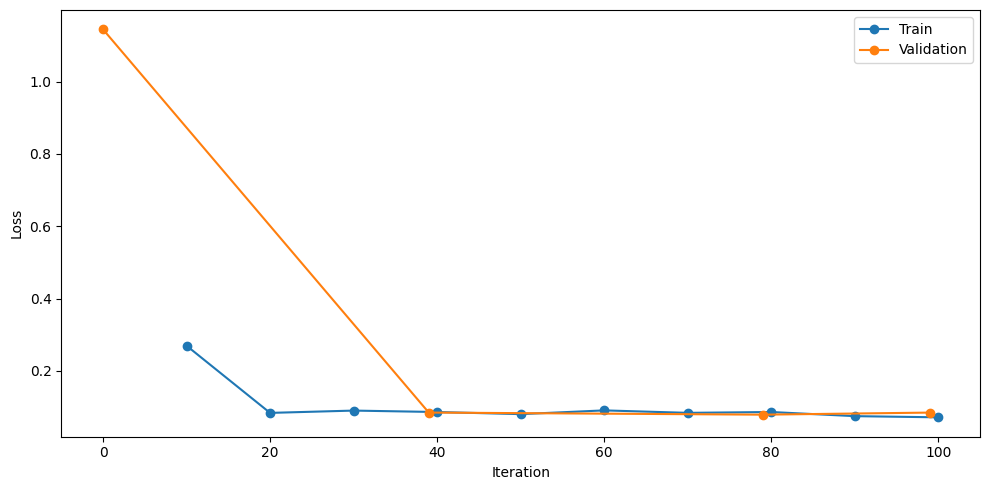

In [34]:
train_its, train_losses = zip(*metrics.train_losses)
val_its, val_losses = zip(*metrics.val_losses)

plt.figure(figsize=(10, 5))
plt.plot(train_its, train_losses, "-o", label="Train")
plt.plot(val_its, val_losses, "-o", label="Validation")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

plot_path = RESULTS_DIR / "training_loss_plot.png"
plt.savefig(plot_path)
print(f"Training plot saved to {plot_path}")
plt.show()

## 10. Test Fine-Tuned Model

In [35]:
def run_inference(
    model: nn.Module,
    tokenizer: PreTrainedTokenizer,
    prompt: str,
    max_tokens: int = 38,
    verbose: bool = False,
) -> str:
    """Run inference with an already-loaded model.

    Args:
        model: The model instance to use for inference
        tokenizer: Tokenizer instance
        prompt: User prompt/instruction
        max_tokens: Maximum tokens to generate (default: 100)
        verbose: Whether to print generation details (default: False)

    Returns:
        Generated response string
    """
    # Generate response
    response = generate(
        model,
        tokenizer,
        prompt=prompt,
        max_tokens=max_tokens,
        verbose=verbose,
    )

    # Clean up response - extract only JSON part
    response = response.strip()

    # Try to extract JSON from response
    if "{" in response and "}" in response:
        start = response.find("{")
        end = response.rfind("}") + 1
        response = response[start:end]

    return response

In [36]:
model_lora, *_ = load(MODEL_NAME, adapter_path=str(ADAPTER_PATH))

test_sample = train_set[4]
prompt = test_sample["instruction"]

messages = [{"role": "user", "content": prompt}]
prompt_text = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)

if not isinstance(prompt_text, str):
    raise TypeError(f"Expected string prompt, got {type(prompt_text)}")

print(f"Testing model with prompt: '{prompt}'")
print(f"Expected output: {test_sample['output']}\n")
response = run_inference(
    model_lora,
    tokenizer,
    prompt=prompt_text,
    max_tokens=38,
    verbose=True,
)

print(f"Model response: {response}")

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Testing model with prompt: 'Você é um especialista no ensino de redação narrativa para alunos do ensino fundamental. Dada uma determinada entrada (uma redação narrativa), seu papel é avaliá-la nas seguintes competências: registro formal, coerência temática, estrutura retórica narrativa e coesão. Sua nota deve ir de 1 à 5, sendo 1 a menor nota e 5 a maior. A saída deve ser um dicionário com as notas de cada competência, por exemplo: {"formal_register": 5, "themetic_coherence": 2, "narrative_rhetorical_structure": 4, "cohesion": 3}

Tema: Eu encontrei em cima do armário alguns potes com tinta. Então resolvi pintar na parede do meu quarto alguns animais. Tempo depois, quando voltei no quarto, não havia mais nenhuma pintura e as roupas da gaveta estavam espalhadas pelo chão.

era uma vez uma menina Que esta  uque faze
e um dia ela a algns tintas e Pintou o seu quarto
 com alguns animais Para Pinta o seu quarto o e a filha foi
  com a sua mãe e condo a filha chegou e o 
  estava sem cor e a

In [37]:
def run_model_on_test_set(
    model_name: str,
    tokenizer: PreTrainedTokenizer,
    test_data: list[dict[str, str]],
    adapter_path: str | Path,
    output_file: str | Path,
    max_tokens: int = 39,
    verbose: bool = False,
) -> pd.DataFrame:
    """Run inference on all test samples and save results.
    
    Args:
        model_name: Name or path of the base model
        tokenizer: Tokenizer instance
        test_data: List of test samples with 'instruction' and 'output' keys
        adapter_path: Path to the LoRA adapter
        output_file: Path to save results (JSONL format)
        max_tokens: Maximum tokens to generate (default: 38)
        verbose: Whether to print generation details (default: False)
        
    Returns:
        DataFrame with results
    """
    output_file = Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    
    # Load model once for all samples
    print(f"Loading model with adapter from {adapter_path}...")
    model, *_ = load(model_name, adapter_path=str(adapter_path))
    
    results = []
    total_samples = len(test_data)
    
    print(f"Evaluating {total_samples} test samples...")
    print(f"Results will be saved to: {output_file}")
    
    for i, sample in enumerate(test_data, 1):
        try:
            # Get instruction and expected output
            instruction = sample["instruction"]
            expected_output = sample.get("output", "")

            messages = [{"role": "user", "content": instruction}]
            prompt_text = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )

            if not isinstance(prompt_text, str):
                raise TypeError(f"Expected string prompt, got {type(prompt_text)}")
            
            # Run inference
            generated_output = run_inference(
                model,
                tokenizer,
                prompt=prompt_text,
                max_tokens=max_tokens,
                verbose=verbose,
            )
            
            # Store result
            result = {
                "sample_id": i - 1,
                "instruction": instruction,
                "expected_output": expected_output,
                "generated_output": generated_output,
                "dataset_source": sample.get("dataset_source", ""),
            }
            results.append(result)
            
            # Progress update
            if i % 10 == 0 or i == total_samples:
                print(f"Processed {i}/{total_samples} samples")
                
        except Exception as e:
            print(f"Error processing sample {i}: {e}")
            # Store error result
            results.append({
                "sample_id": i - 1,
                "instruction": sample.get("instruction", ""),
                "expected_output": sample.get("output", ""),
                "generated_output": f"ERROR: {str(e)}",
                "dataset_source": sample.get("dataset_source", ""),
            })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Save to JSONL
    results_df.to_json(output_file, orient="records", lines=True)
    print(f"\n✓ Results saved to {output_file}")
    print(f"Total samples processed: {len(results_df)}")
    
    return results_df


# Run evaluation on test set
test_results_file = RESULTS_DIR / "test_results.jsonl"

test_results_df = run_model_on_test_set(
    model_name=MODEL_NAME,
    tokenizer=tokenizer,
    test_data=test_set,
    adapter_path=ADAPTER_PATH,
    output_file=test_results_file,
    max_tokens=40,
    verbose=False,
)

Loading model with adapter from /Users/hyan/Workspaces/aibox-nes-slms/adapters/smol-lm-360m-it...


Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Evaluating 370 test samples...
Results will be saved to: /Users/hyan/Workspaces/aibox-nes-slms/data/processed/smol-lm-360m-it/test_results.jsonl
Processed 10/370 samples
Processed 20/370 samples
Processed 30/370 samples
Processed 40/370 samples
Processed 50/370 samples
Processed 60/370 samples
Processed 70/370 samples
Processed 80/370 samples
Processed 90/370 samples
Processed 100/370 samples
Processed 110/370 samples
Processed 120/370 samples
Processed 130/370 samples
Processed 140/370 samples
Processed 150/370 samples
Processed 160/370 samples
Processed 170/370 samples
Processed 180/370 samples
Processed 190/370 samples
Processed 200/370 samples
Processed 210/370 samples
Processed 220/370 samples
Processed 230/370 samples
Processed 240/370 samples
Processed 250/370 samples
Processed 260/370 samples
Processed 270/370 samples
Processed 280/370 samples
Processed 290/370 samples
Processed 300/370 samples
Processed 310/370 samples
Processed 320/370 samples
Processed 330/370 samples
Proces

In [38]:
def analyze_results(results_df: pd.DataFrame) -> dict[str, Any]:
    """Analyze test results and compute basic statistics.
    
    Args:
        results_df: DataFrame with test results
        
    Returns:
        Dictionary with analysis metrics
    """
    analysis = {
        "total_samples": len(results_df),
        "successful_generations": len(results_df[~results_df["generated_output"].str.startswith("ERROR")]),
        "errors": len(results_df[results_df["generated_output"].str.startswith("ERROR")]),
        "avg_output_length": results_df["generated_output"].str.len().mean(),
    }
    
    print("\n--- Test Results Analysis ---")
    print(f"Total samples: {analysis['total_samples']}")
    print(f"Successful: {analysis['successful_generations']}")
    print(f"Errors: {analysis['errors']}")
    print(f"Avg output length: {analysis['avg_output_length']:.2f} chars")
    
    return analysis


# Run analysis
analysis = analyze_results(test_results_df)


--- Test Results Analysis ---
Total samples: 370
Successful: 370
Errors: 0
Avg output length: 99.00 chars


In [39]:
def parse_evaluation_output(output_str: str) -> dict[str, int] | None:
    """Parse the model output string into a dictionary.
    
    Args:
        output_str: JSON string with evaluation scores
        
    Returns:
        Dictionary with competency scores or None if parsing fails
    """
    try:
        # Handle potential formatting issues
        output_str = output_str.strip()
        if output_str.startswith("ERROR"):
            return None
        
        # Try to parse as JSON
        result = json.loads(output_str)
        
        # Validate expected keys
        expected_keys = {
            "formal_register",
            "thematic_coherence",
            "narrative_rhetorical_structure",
            "cohesion",
        }
        
        if not all(key in result for key in expected_keys):
            return None
            
        # Convert to integers
        return {k: int(v) for k, v in result.items() if k in expected_keys}
        
    except (json.JSONDecodeError, ValueError, TypeError):
        return None


def evaluate_multilabel_classification(
    results_df: pd.DataFrame,
    competencies: list[str] | None = None,
) -> dict[str, Any]:
    """Evaluate multilabel classification results for essay grading.
    
    Args:
        results_df: DataFrame with 'expected_output' and 'generated_output' columns
        competencies: List of competency names to evaluate (default: all 4 competencies)
        
    Returns:
        Dictionary with evaluation metrics
    """
    if competencies is None:
        competencies = [
            "formal_register",
            "thematic_coherence",
            "narrative_rhetorical_structure",
            "cohesion",
        ]
    
    # Parse outputs
    expected_parsed = []
    generated_parsed = []
    valid_samples = 0
    parsing_errors = 0
    
    for _, row in results_df.iterrows():
        expected = parse_evaluation_output(row["expected_output"])
        generated = parse_evaluation_output(row["generated_output"])
        
        if expected is not None and generated is not None:
            expected_parsed.append(expected)
            generated_parsed.append(generated)
            valid_samples += 1
        else:
            parsing_errors += 1
    
    if valid_samples == 0:
        print("❌ No valid samples to evaluate!")
        return {"error": "No valid samples"}
    
    print(f"✓ Valid samples: {valid_samples}/{len(results_df)}")
    print(f"✗ Parsing errors: {parsing_errors}\n")
    
    # Prepare data for metrics
    results = {
        "total_samples": len(results_df),
        "valid_samples": valid_samples,
        "parsing_errors": parsing_errors,
        "competencies": {},
        "overall": {},
    }
    
    # Evaluate each competency separately
    for competency in competencies:
        y_true = [sample[competency] for sample in expected_parsed]
        y_pred = [sample[competency] for sample in generated_parsed]
        
        # Calculate metrics
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
        recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
        
        # Exact match accuracy (correct grade)
        exact_matches = sum(1 for t, p in zip(y_true, y_pred) if t == p)
        exact_match_rate = exact_matches / len(y_true)
        
        # Off-by-one accuracy (within 1 point)
        off_by_one = sum(1 for t, p in zip(y_true, y_pred) if abs(t - p) <= 1)
        off_by_one_rate = off_by_one / len(y_true)
        
        results["competencies"][competency] = {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "exact_match_rate": exact_match_rate,
            "off_by_one_rate": off_by_one_rate,
            "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        }
        
        print(f"\n--- {competency.replace('_', ' ').title()} ---")
        print(f"Accuracy:          {accuracy:.4f}")
        print(f"Precision:         {precision:.4f}")
        print(f"Recall:            {recall:.4f}")
        print(f"F1 Score:          {f1:.4f}")
        print(f"Exact Match:       {exact_match_rate:.4f} ({exact_matches}/{len(y_true)})")
        print(f"Off-by-One Match:  {off_by_one_rate:.4f} ({off_by_one}/{len(y_true)})")
    
    # Calculate overall metrics (micro-average across all competencies)
    all_y_true = []
    all_y_pred = []
    for competency in competencies:
        all_y_true.extend([sample[competency] for sample in expected_parsed])
        all_y_pred.extend([sample[competency] for sample in generated_parsed])
    
    overall_accuracy = accuracy_score(all_y_true, all_y_pred)
    overall_precision = precision_score(all_y_true, all_y_pred, average="weighted", zero_division=0)
    overall_recall = recall_score(all_y_true, all_y_pred, average="weighted", zero_division=0)
    overall_f1 = f1_score(all_y_true, all_y_pred, average="weighted", zero_division=0)
    
    exact_matches = sum(1 for t, p in zip(all_y_true, all_y_pred) if t == p)
    exact_match_rate = exact_matches / len(all_y_true)
    
    off_by_one = sum(1 for t, p in zip(all_y_true, all_y_pred) if abs(t - p) <= 1)
    off_by_one_rate = off_by_one / len(all_y_true)
    
    results["overall"] = {
        "accuracy": overall_accuracy,
        "precision": overall_precision,
        "recall": overall_recall,
        "f1_score": overall_f1,
        "exact_match_rate": exact_match_rate,
        "off_by_one_rate": off_by_one_rate,
    }
    
    print(f"\n{'='*50}")
    print("--- Overall Performance (All Competencies) ---")
    print(f"{'='*50}")
    print(f"Accuracy:          {overall_accuracy:.4f}")
    print(f"Precision:         {overall_precision:.4f}")
    print(f"Recall:            {overall_recall:.4f}")
    print(f"F1 Score:          {overall_f1:.4f}")
    print(f"Exact Match:       {exact_match_rate:.4f}")
    print(f"Off-by-One Match:  {off_by_one_rate:.4f}")
    
    return results


# Run evaluation
evaluation_results = evaluate_multilabel_classification(test_results_df)

# Save evaluation results
eval_results_file = RESULTS_DIR / "evaluation_metrics.json"
with open(eval_results_file, "w") as f:
    json.dump(evaluation_results, f, indent=2)
print(f"\n✓ Evaluation metrics saved to {eval_results_file}")

✓ Valid samples: 370/370
✗ Parsing errors: 0


--- Formal Register ---
Accuracy:          0.6730
Precision:         0.4529
Recall:            0.6730
F1 Score:          0.5414
Exact Match:       0.6730 (249/370)
Off-by-One Match:  0.9622 (356/370)

--- Thematic Coherence ---
Accuracy:          0.4189
Precision:         0.2670
Recall:            0.4189
F1 Score:          0.2585
Exact Match:       0.4189 (155/370)
Off-by-One Match:  0.6919 (256/370)

--- Narrative Rhetorical Structure ---
Accuracy:          0.4730
Precision:         0.4372
Recall:            0.4730
F1 Score:          0.4464
Exact Match:       0.4730 (175/370)
Off-by-One Match:  0.9189 (340/370)

--- Cohesion ---
Accuracy:          0.6946
Precision:         0.4825
Recall:            0.6946
F1 Score:          0.5694
Exact Match:       0.6946 (257/370)
Off-by-One Match:  0.9432 (349/370)

--- Overall Performance (All Competencies) ---
Accuracy:          0.5649
Precision:         0.5028
Recall:            0.5649
F1 Score:    